In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('fivethirtyeight')
sns.set_palette('husl')

# Load our clean dataset
df = pd.read_csv("data/cleaned/fifa24_top5_leagues.csv")

print(f"Dataset loaded!")
print(f"Players: {len(df)}")
print(f"Columns: {len(df.columns)}")
df.head()

Dataset loaded!
Players: 3467
Columns: 40


,short_name,long_name,age,nationality_name,player_positions,club_name,league_name,league_level,value_eur,wage_eur,...,power_stamina,power_strength,movement_acceleration,movement_sprint_speed,movement_agility,defending_marking_awareness,defending_standing_tackle,mentality_positioning,work_rate,body_type
0,K. Mbappé,Kylian Mbappé Lottin,24,France,"ST, LW",Paris Saint Germain,Ligue 1,1.0,181500000.0,230000.0,...,88,77,97,97,93,26,34,93,High/Low,Unique
1,E. Haaland,Erling Braut Haaland,22,Norway,ST,Manchester City,Premier League,1.0,185000000.0,340000.0,...,76,93,82,94,76,38,47,96,High/Medium,Unique
2,K. De Bruyne,Kevin De Bruyne,32,Belgium,"CM, CAM",Manchester City,Premier League,1.0,103000000.0,350000.0,...,88,74,72,72,74,66,70,88,High/Medium,Unique
3,R. Lewandowski,Robert Lewandowski,34,Poland,ST,FC Barcelona,La Liga,1.0,58000000.0,340000.0,...,76,89,76,75,77,35,42,94,High/Medium,Unique
4,T. Courtois,Thibaut Nicolas Marc Courtois,31,Belgium,GK,Real Madrid,La Liga,1.0,63000000.0,250000.0,...,38,70,42,52,63,20,18,13,Medium/Medium,Unique


In [2]:
# Data Quality Check
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

print(f"\n=== DATA TYPES ===")
print(df.dtypes)

print(f"\n=== BASIC STATS ===")
print(df[['age', 'overall', 'potential', 'value_eur', 'wage_eur']].describe())

=== MISSING VALUES ===
pace                  402
shooting              402
passing               402
defending             402
dribbling             402
physic                402
release_clause_eur    233
dtype: int64

=== DATA TYPES ===
short_name                         str
long_name                          str
age                              int64
nationality_name                   str
player_positions                   str
club_name                          str
league_name                        str
league_level                   float64
value_eur                      float64
wage_eur                       float64
release_clause_eur             float64
overall                          int64
potential                        int64
international_reputation         int64
pace                           float64
shooting                       float64
passing                        float64
dribbling                      float64
defending                      float64
physic               

In [3]:
# Handle Missing Values

# 1. Pace/Shooting etc missing = Goalkeepers
# Fill with 0 for GKs as they don't have outfield stats
outfield_stats = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
df[outfield_stats] = df[outfield_stats].fillna(0)

# 2. Release clause - fill with 0 (means no release clause)
df['release_clause_eur'] = df['release_clause_eur'].fillna(0)

# 3. Verify no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum().sum())
print("✅ All clean!" if df.isnull().sum().sum() == 0 else "❌ Still has missing values")

Missing values after cleaning:
0
✅ All clean!


# ⚽ Football Intelligence Dashboard - EDA

## Business Questions We're Answering:
1. Which league has the best players?
2. Which league pays the most?
3. What makes a player valuable?
4. Who are the most undervalued players?
5. How does age affect performance and value?
6. Which nation produces the best players?
7. Position-wise analysis — who earns most?

                avg_overall  avg_potential    avg_value  total_players
league_name                                                           
La Liga               73.05          78.30  11119614.09            596
Premier League        72.91          78.63  12747444.77            679
Serie A               72.51          75.95   7811728.03            842
Ligue 1               71.22          77.26   7028070.00            500
Bundesliga            69.16          74.94   5980905.88            850


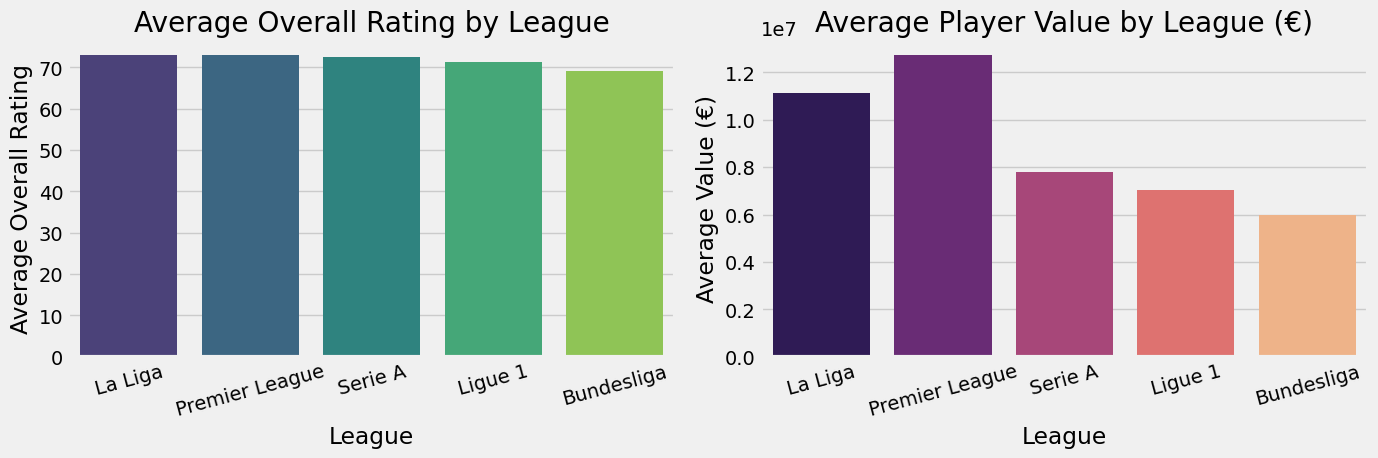

In [4]:
# Q1 - League Quality Comparison
league_stats = df.groupby('league_name').agg(
    avg_overall=('overall', 'mean'),
    avg_potential=('potential', 'mean'),
    avg_value=('value_eur', 'mean'),
    total_players=('short_name', 'count')
).round(2).sort_values('avg_overall', ascending=False)

print(league_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Average Overall Rating
sns.barplot(x=league_stats.index, y=league_stats['avg_overall'], ax=axes[0], palette='viridis')
axes[0].set_title('Average Overall Rating by League')
axes[0].set_xlabel('League')
axes[0].set_ylabel('Average Overall Rating')
axes[0].tick_params(axis='x', rotation=15)

# Chart 2 - Average Player Value
sns.barplot(x=league_stats.index, y=league_stats['avg_value'], ax=axes[1], palette='magma')
axes[1].set_title('Average Player Value by League (€)')
axes[1].set_xlabel('League')
axes[1].set_ylabel('Average Value (€)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 📌 Finding - Q1: Which League Has The Best Players?

**La Liga edges out the Premier League** in average player quality 
(73.05 vs 72.91), but the **Premier League pays significantly more** 
— €12.7M average value vs La Liga's €11.1M.

The **Bundesliga** tells the most interesting story — lowest rated 
and lowest valued players, but the most players overall (850). 
This reflects Germany's philosophy of developing young talent 
rather than buying expensive superstars.

**Key Insight:** Premier League clubs pay a premium — their average 
player value is **double** that of Bundesliga clubs despite only a 
3-point difference in average overall rating.

                avg_wage  median_wage  max_wage  min_wage
league_name                                              
Premier League  48423.27      37000.0  350000.0     500.0
La Liga         30189.77      20000.0  340000.0     500.0
Serie A         25440.80      17000.0  165000.0     500.0
Ligue 1         20201.80      15000.0  230000.0     500.0
Bundesliga      16304.24      10000.0  170000.0     500.0


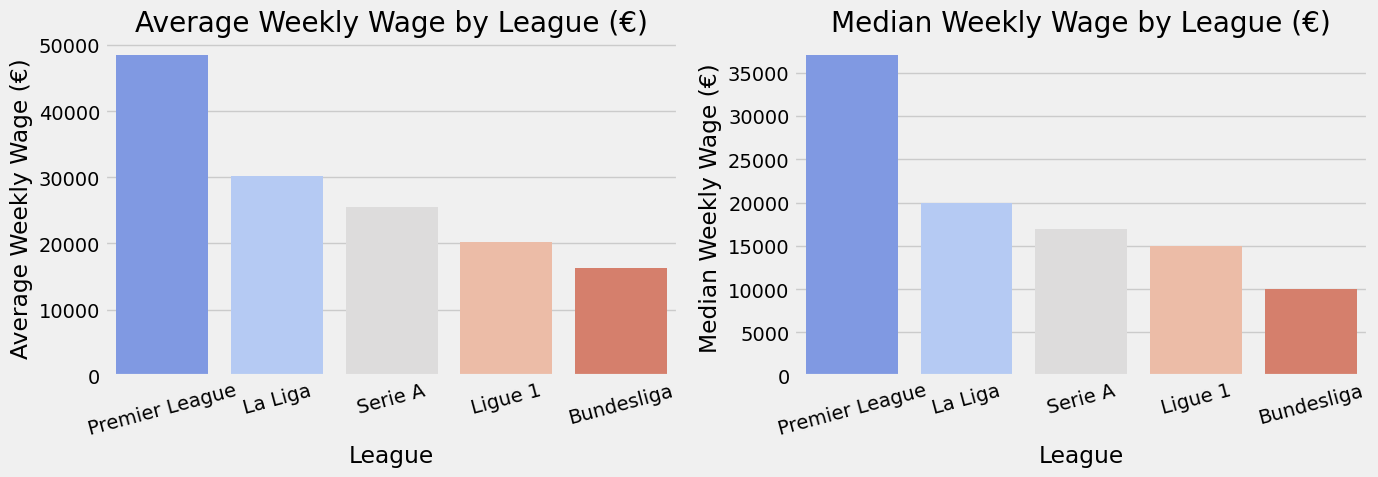

In [5]:
# Q2 - League Wage Analysis
wage_stats = df.groupby('league_name').agg(
    avg_wage = ('wage_eur', 'mean'),
    median_wage=('wage_eur', 'median'),
    max_wage=('wage_eur', 'max'),
    min_wage=('wage_eur', 'min')
).round(2).sort_values('avg_wage', ascending=False)

print(wage_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Average Wage
sns.barplot(x=wage_stats.index, y=wage_stats['avg_wage'], ax=axes[0], palette='coolwarm')
axes[0].set_title('Average Weekly Wage by League (€)')
axes[0].set_xlabel('League')
axes[0].set_ylabel('Average Weekly Wage (€)')
axes[0].tick_params(axis='x', rotation=15)

# Chart 2 - Median Wage
sns.barplot(x=wage_stats.index, y=wage_stats['median_wage'], ax=axes[1], palette='coolwarm')
axes[1].set_title('Median Weekly Wage by League (€)')
axes[1].set_xlabel('League')
axes[1].set_ylabel('Median Weekly Wage (€)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 📌 Finding - Q2: Which League Pays The Most?

**Premier League is the clear winner** — average weekly wage of 
€48,423 is nearly 3x the Bundesliga (€16,304).

Most revealing stat: **EPL's median wage is €37,000** — meaning 
even a typical average Premier League player earns more than 
what most La Liga or Serie A players earn.

**Ligue 1's average (€20,202) is misleading** — Mbappé's 
reported €230,000/week wage significantly inflates this figure. 
The median of €15,000 tells the real story of what most 
Ligue 1 players actually earn.

**Key Insight:** The Premier League's financial dominance isn't 
just about superstars — it's systemic. Even bench players 
earn more than starters in other leagues.

Correlation with Market Value:
wage_eur                    0.823429
overall                     0.667261
international_reputation    0.659236
potential                   0.641262
skill_moves                 0.283765
passing                     0.264061
shooting                    0.260604
dribbling                   0.247383
physic                      0.186863
weak_foot                   0.185549
pace                        0.182644
defending                   0.155056
age                         0.065881
Name: value_eur, dtype: float64


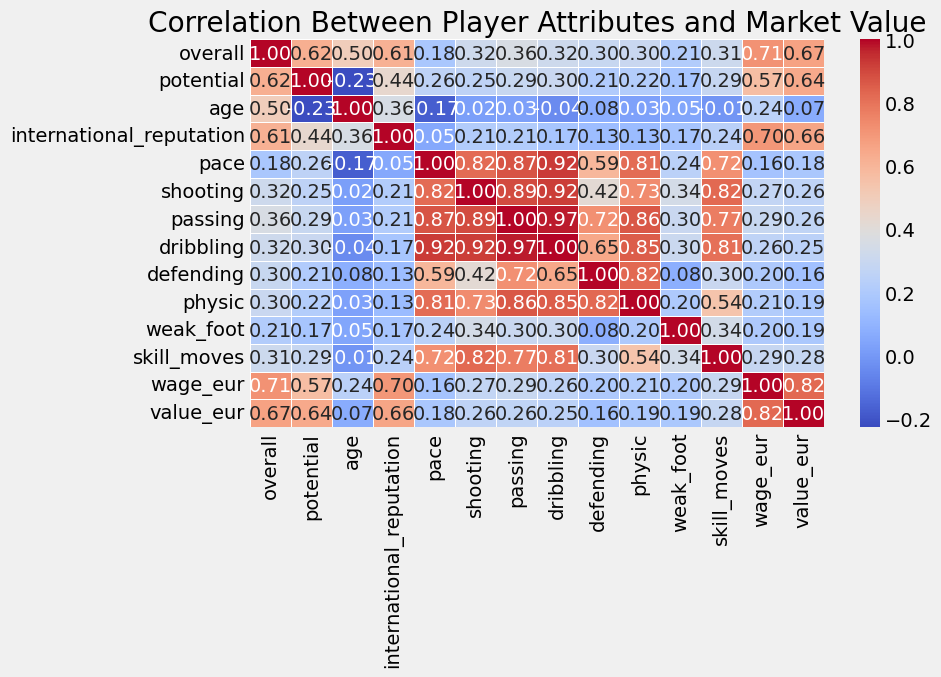

In [6]:
# Q3 - What Makes A Player Valuable?
# Correlation of player attributes with market value

# Select numeric columns that affect value
value_factors = [
    'overall', 'potential', 'age', 'international_reputation',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'weak_foot', 'skill_moves', 'wage_eur'
]

# Calculate correlation with value_eur
correlations = df[value_factors + ['value_eur']].corr()['value_eur'][:-1].sort_values(ascending=False)
print("Correlation with Market Value:")
print(correlations)

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[value_factors + ['value_eur']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Between Player Attributes and Market Value')
plt.tight_layout()
plt.show()

## 📌 Finding - Q3: What Makes A Player Valuable?

**Top 4 value drivers:**
1. Weekly Wage (0.82) — strongest predictor
2. Overall Rating (0.67) — skill matters
3. International Reputation (0.66) — fame = money
4. Potential (0.64) — future matters as much as present

**Surprising finding:** Age has near-zero correlation (0.07) 
with market value — a player's value is driven by their 
quality and reputation, not their age alone.

**Defenders are undervalued** — defending stats show the 
weakest correlation (0.15) with market value, confirming 
that the transfer market consistently undervalues defensive 
players compared to attackers.

In [7]:
# Q4 - Undervalued Players Analysis

# Step 1 - Remove players with 0 or very low value
df_valued = df[df['value_eur'] > 500000].copy()

# Step 2 - Create Value Score
# Higher overall rating per million euros = undervalued
df_valued['value_score'] = df_valued['overall'] / (df_valued['value_eur'] / 1000000)

# Step 3 - Filter only quality players (overall >= 78)
df_quality = df_valued[df_valued['overall'] >= 78].copy()

# Step 4 - Sort by value score
undervalued = df_quality.sort_values('value_score', ascending=False)

print("🏆 Top 15 Most Undervalued Quality Players:")
print(undervalued[['short_name', 'club_name', 'league_name', 
                    'overall', 'value_eur', 'age', 'value_score']]
      .head(15).to_string())

🏆 Top 15 Most Undervalued Quality Players:
            short_name          club_name     league_name  overall  value_eur  age  value_score
618             Guaita      Celta de Vigo         La Liga       78  1600000.0   36    48.750000
631       A. Marchesín      Celta de Vigo         La Liga       78  1600000.0   35    48.750000
478       Ł. Fabiański    West Ham United  Premier League       79  1900000.0   38    41.578947
477        S. Mandanda             Rennes         Ligue 1       79  1900000.0   38    41.578947
476        A. Consigli           Sassuolo         Serie A       79  1900000.0   36    41.578947
527         Emelvinson         Bragantino         Serie A       79  1900000.0   35    41.578947
365           C. Bravo         Real Betis         La Liga       80  2300000.0   40    34.782609
653        M. Dúbravka   Newcastle United  Premier League       78  2400000.0   34    32.500000
615              Dante               Nice         Ligue 1       78  2500000.0   39    31.2000

In [8]:
# Improved Undervalued Analysis
# Filter: Overall >= 78, Age <= 30, Value > 1M

df_undervalued = df[
    (df['overall'] >= 78) &
    (df['age'] <= 30) &
    (df['value_eur'] > 1000000)
].copy()

# Value Score
df_undervalued['value_score'] = df_undervalued['overall'] / (df_undervalued['value_eur'] / 1000000)

# Sort
df_undervalued = df_undervalued.sort_values('value_score', ascending=False)

print("💎 Top 15 Undervalued Players (Age <= 30, Overall >= 78):")
print(df_undervalued[['short_name', 'club_name', 'league_name',
                       'overall', 'value_eur', 'age', 
                       'player_positions', 'value_score']]
      .head(15).to_string())

💎 Top 15 Undervalued Players (Age <= 30, Overall >= 78):
          short_name                club_name     league_name  overall   value_eur  age player_positions  value_score
603        A. Areola          West Ham United  Premier League       78  10500000.0   30               GK     7.428571
498        S. Ortega          Manchester City  Premier League       79  11500000.0   30               GK     6.869565
517          José Sá  Wolverhampton Wanderers  Premier League       79  11500000.0   30               GK     6.869565
502        F. Rønnow          FC Union Berlin      Bundesliga       79  11500000.0   30               GK     6.869565
594         Y. Mvogo                  Lorient         Ligue 1       78  11500000.0   29               GK     6.782609
641     S. Kolašinac                 Atalanta         Serie A       78  11500000.0   30           CB, LB     6.782609
656        J. Gradit                     Lens         Ligue 1       78  11500000.0   30               CB     6.782609

In [9]:
# Q4 - Undervalued Players by Position

positions = {
    'Goalkeeper': ['GK'],
    'Defender': ['CB', 'LB', 'RB', 'LWB', 'RWB'],
    'Midfielder': ['CDM', 'CM', 'CAM', 'LM', 'RM'],
    'Forward': ['ST', 'CF', 'LW', 'RW', 'LF', 'RF']
}

df_undervalued = df[
    (df['overall'] >= 78) &
    (df['age'] <= 29) &
    (df['value_eur'] > 1000000)
].copy()

df_undervalued['value_score'] = df_undervalued['overall'] / (df_undervalued['value_eur'] / 1000000)

print("💎 Top 5 Undervalued Players By Position:\n")

for pos_group, pos_list in positions.items():
    # Filter by position
    mask = df_undervalued['player_positions'].apply(
        lambda x: any(p in str(x).split(', ') for p in pos_list)
    )
    group_df = df_undervalued[mask].sort_values('value_score', ascending=False)
    
    print(f"=== {pos_group} ===")
    print(group_df[['short_name', 'club_name', 'league_name',
                     'overall', 'value_eur', 'age', 'value_score']]
          .head(5).to_string())
    print()

💎 Top 5 Undervalued Players By Position:

=== Goalkeeper ===
          short_name       club_name league_name  overall   value_eur  age  value_score
594         Y. Mvogo         Lorient     Ligue 1       78  11500000.0   29     6.782609
514  S. Dimitrievski  Rayo Vallecano     La Liga       79  12000000.0   29     6.583333
466         J. Musso        Atalanta     Serie A       79  13500000.0   29     5.851852
591      P. Rajković        Mallorca     La Liga       78  14000000.0   27     5.571429
407    Héniton Pires        Flamengo     Serie A       80  16000000.0   27     5.000000

=== Defender ===
          short_name                club_name     league_name  overall   value_eur  age  value_score
651      H. Hateboer                 Atalanta         Serie A       78  12500000.0   29         6.24
646           P. Max      Eintracht Frankfurt      Bundesliga       78  12500000.0   29         6.24
660          M. Wolf        Borussia Dortmund      Bundesliga       78  12500000.0   28   

## 📌 Finding - Q4: Who Are The Most Undervalued Players?

Using a Value Score (Overall Rating ÷ Value in millions), 
we identified undervalued players in each position 
among players aged under 29 with overall rating 78+.

**Key Hidden Gems:**
- 🧤 GK: Y. Mvogo (Lorient) — rated 78, value €11.5M
- 🛡️ DEF: Héctor Bellerín (Real Betis) — experienced, only €12.5M
- ⚙️ MID: M. Lemina (Wolves) — best value midfielder at €12M  
- ⚽ FWD: A. Belotti (Roma) — proven striker at just €14M

**Pattern:** Most undervalued players are in Ligue 1 and 
Serie A — confirming that Premier League and La Liga 
consistently overpay for similar quality players.

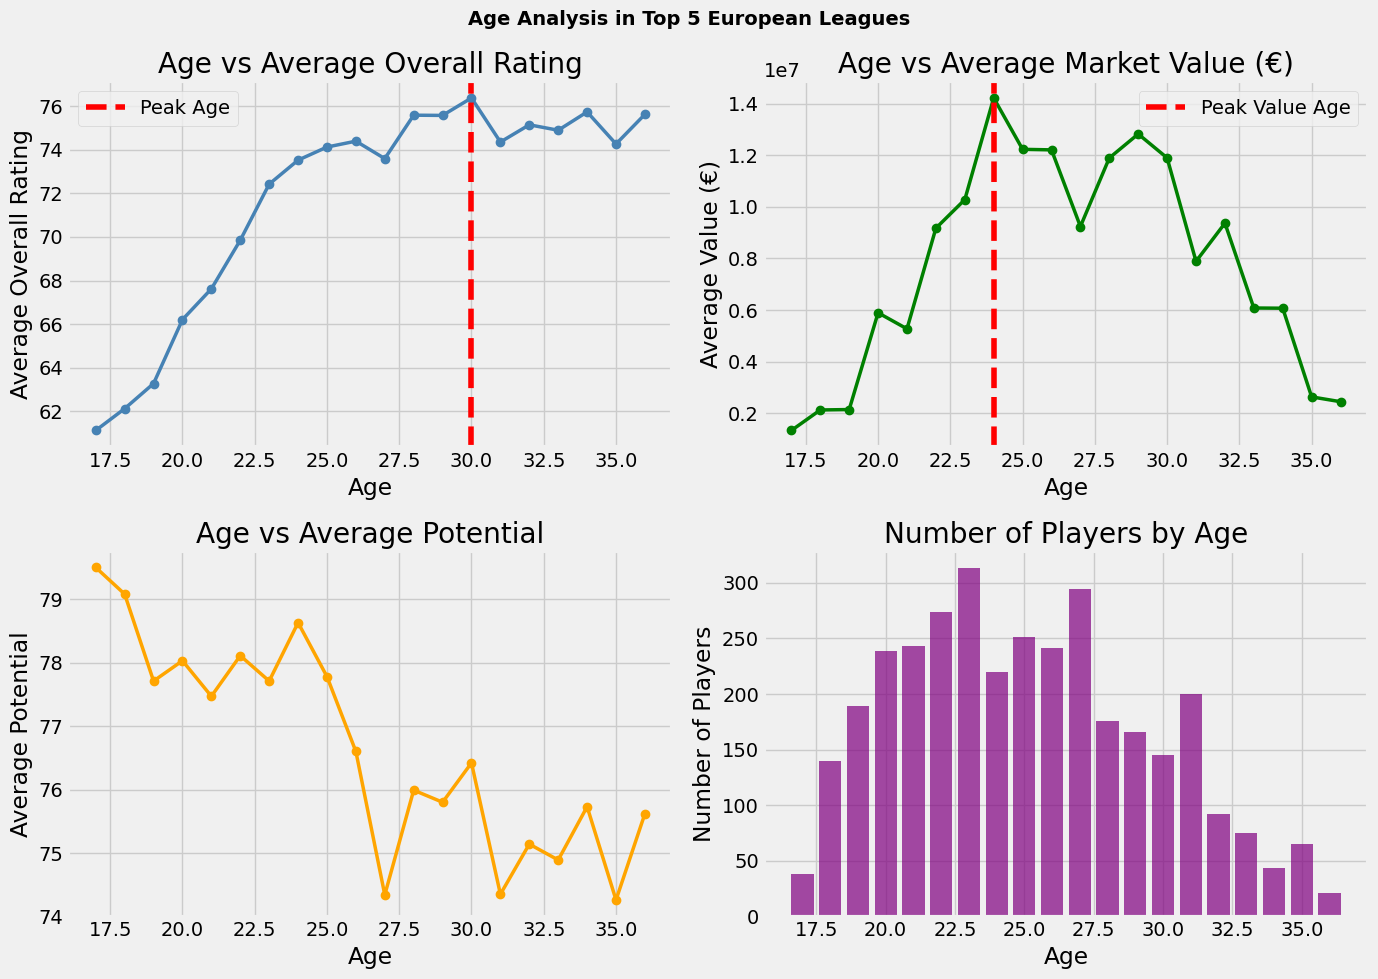

Peak Performance Age: 30
Peak Value Age: 24
Most Common Age: 23


In [10]:
# Q5 - Age vs Performance and Value Analysis

# Group by age
age_stats = df.groupby('age').agg(
    avg_overall=('overall', 'mean'),
    avg_potential=('potential', 'mean'),
    avg_value=('value_eur', 'mean'),
    player_count=('short_name', 'count')
).round(2)

# Only keep ages with enough players (at least 20)
age_stats = age_stats[age_stats['player_count'] >= 20]

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 - Age vs Overall Rating
axes[0,0].plot(age_stats.index, age_stats['avg_overall'], 
               color='steelblue', linewidth=2.5, marker='o')
axes[0,0].set_title('Age vs Average Overall Rating')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Average Overall Rating')
axes[0,0].axvline(x=age_stats['avg_overall'].idxmax(), 
                   color='red', linestyle='--', label='Peak Age')
axes[0,0].legend()

# Chart 2 - Age vs Market Value
axes[0,1].plot(age_stats.index, age_stats['avg_value'], 
               color='green', linewidth=2.5, marker='o')
axes[0,1].set_title('Age vs Average Market Value (€)')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Average Value (€)')
axes[0,1].axvline(x=age_stats['avg_value'].idxmax(), 
                   color='red', linestyle='--', label='Peak Value Age')
axes[0,1].legend()

# Chart 3 - Age vs Potential
axes[1,0].plot(age_stats.index, age_stats['avg_potential'], 
               color='orange', linewidth=2.5, marker='o')
axes[1,0].set_title('Age vs Average Potential')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Average Potential')

# Chart 4 - Player Count by Age
axes[1,1].bar(age_stats.index, age_stats['player_count'], 
               color='purple', alpha=0.7)
axes[1,1].set_title('Number of Players by Age')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Number of Players')

plt.suptitle('Age Analysis in Top 5 European Leagues', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print peak ages
print(f"Peak Performance Age: {age_stats['avg_overall'].idxmax()}")
print(f"Peak Value Age: {age_stats['avg_value'].idxmax()}")
print(f"Most Common Age: {age_stats['player_count'].idxmax()}")

## 📌 Finding - Q5: How Does Age Affect Performance and Value?

Performance and market value **peak at different ages** — average overall 
rating is highest at **age 30**, but average market value peaks earlier, 
at **age 24**.

This makes business sense: clubs pay a premium for **remaining prime years**, 
not just current skill. A 30-year-old and a 24-year-old can have similar 
overall ratings, but the 24-year-old commands a higher price because they 
have more peak years ahead of them.

**Key Insight:** This explains the Q3 finding that age has near-zero raw 
correlation with value (0.07) — age's effect isn't linear, it's a trade-off 
between current ability and remaining career length, which cancels out in 
a simple correlation.

Top 10 nations by average overall rating (min 15 players):
                  avg_overall  avg_potential  player_count
nationality_name                                          
Portugal                76.56          80.77            61
Netherlands             76.02          80.27            63
Argentina               75.84          80.63            73
Uruguay                 75.56          79.96            27
Japan                   74.71          78.41            17
Switzerland             74.44          78.94            36
Croatia                 73.84          77.63            38
Colombia                73.81          78.57            21
Czech Republic          73.59          77.76            17
Belgium                 73.55          79.45            53


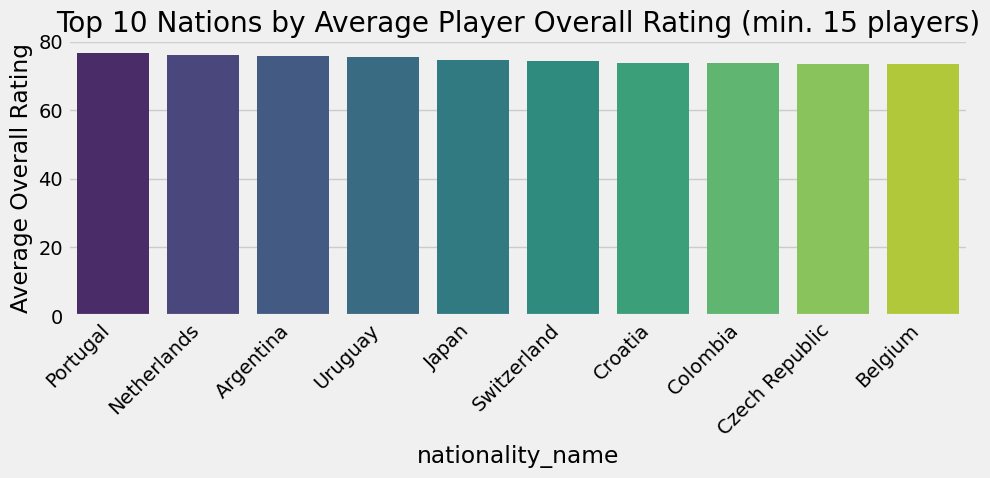

In [11]:
# Q6 - Which Nation Produces The Best Players?
nation_stats = df.groupby('nationality_name').agg(
    avg_overall=('overall', 'mean'),
    avg_potential=('potential', 'mean'),
    player_count=('short_name', 'count')
).round(2)

# Only nations with a meaningful sample size (avoid noise from 1-2 player countries)
nation_stats = nation_stats[nation_stats['player_count'] >= 15].sort_values('avg_overall', ascending=False)

print("Top 10 nations by average overall rating (min 15 players):")
print(nation_stats.head(10))

# Visualization
top10 = nation_stats.head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top10.index, y=top10['avg_overall'], palette='viridis')
plt.title('Top 10 Nations by Average Player Overall Rating (min. 15 players)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Overall Rating')
plt.tight_layout()
plt.show()

## 📌 Finding - Q6: Which Nation Produces The Best Players?

Among nations with at least 15 players in the top 5 European leagues, 
**Portugal** produces the highest average quality (76.56 overall), 
narrowly ahead of the **Netherlands** (76.02) and **Argentina** (75.84).

**Interesting outlier:** Austria has 231 players in the dataset — one of 
the largest nationality groups — but the lowest average overall (65.44) 
of any nation with a meaningful sample. This suggests Austrian players 
largely fill squad-depth roles across the leagues rather than headline 
positions.

**Key Insight:** Player quality by nation isn't purely about football 
pedigree — it also reflects how many depth-squad players versus genuine 
stars a country sends into Europe's top leagues.

                avg_wage  median_wage    avg_value  avg_overall  player_count
position_group                                                               
Forward         34186.23      21000.0  11507661.54        71.94           650
Midfielder      27574.39      17000.0   9275170.18        71.71          1234
Defender        27272.65      18000.0   7885016.93        72.15          1181
Goalkeeper      19393.78      10000.0   5523233.83        69.74           402


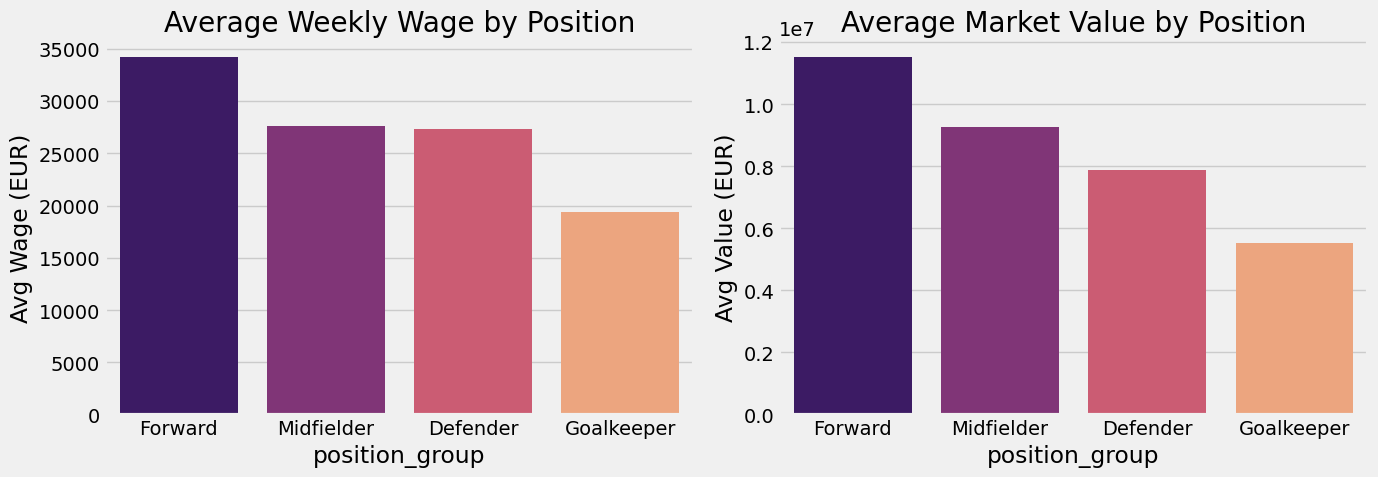

In [12]:
# Q7 - Position-wise Analysis: Who Earns Most?
# player_positions can list multiple roles e.g. 'ST, LW' -> take the primary (first-listed) position
df['primary_position'] = df['player_positions'].apply(lambda x: x.split(',')[0].strip())

position_map = {
    'GK': 'Goalkeeper',
    'CB': 'Defender', 'LB': 'Defender', 'RB': 'Defender', 'LWB': 'Defender', 'RWB': 'Defender',
    'CDM': 'Midfielder', 'CM': 'Midfielder', 'CAM': 'Midfielder', 'LM': 'Midfielder', 'RM': 'Midfielder',
    'ST': 'Forward', 'CF': 'Forward', 'LW': 'Forward', 'RW': 'Forward', 'LF': 'Forward', 'RF': 'Forward'
}
df['position_group'] = df['primary_position'].map(position_map)

pos_stats = df.groupby('position_group').agg(
    avg_wage=('wage_eur', 'mean'),
    median_wage=('wage_eur', 'median'),
    avg_value=('value_eur', 'mean'),
    avg_overall=('overall', 'mean'),
    player_count=('short_name', 'count')
).round(2).sort_values('avg_wage', ascending=False)

print(pos_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=pos_stats.index, y=pos_stats['avg_wage'], ax=axes[0], palette='magma')
axes[0].set_title('Average Weekly Wage by Position')
axes[0].set_ylabel('Avg Wage (EUR)')

sns.barplot(x=pos_stats.index, y=pos_stats['avg_value'], ax=axes[1], palette='magma')
axes[1].set_title('Average Market Value by Position')
axes[1].set_ylabel('Avg Value (EUR)')

plt.tight_layout()
plt.show()

## 📌 Finding - Q7: Position-wise Analysis — Who Earns Most?

**Forwards earn the most** — average weekly wage of €34,186 and average 
market value of €11.5M — despite not having the highest average skill 
rating (71.94 overall, slightly below defenders).

**Defenders are the best value-for-skill** — highest average overall rating 
of any position group (72.15), yet they earn ~20% less than forwards. This 
echoes the Q3 finding that defensive stats correlate weakest with market 
value — the market prices attacking output higher than defensive quality.

**Goalkeepers earn least** — €19,394/week on average, roughly half of 
forwards, and the lowest average value (€5.5M).

**Key Insight:** Position shapes earning potential independent of skill 
level — the market rewards attacking output and visibility over balanced 
quality, reinforcing the Q3 finding that reputation/role matters as much 
as raw ability.